# Grupo 2 — Random Forest (Tráfego)

Primeira aplicação do Random Forest à base tratada do grupo 2. Horizonte: **um horário passo à frente**. Todas as métricas e figuras ficam neste notebook. A escolha das features usa somente validação temporal no treino; T11 ajusta os hiperparâmetros. A comparação com a versão anterior fica no fim do notebook.

In [1]:
from pathlib import Path
import os
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from preparacao_bases import carregar_base_tratada
from features_temporais import preparar_features_base
from funcoes_series_temporais import calcular_importancia_features

## T01 — Base tratada e protocolo

O Excel comum fornece o alvo, a frequência, a seed e o instante fixo de início do teste. O modelo não modifica a base tratada.

In [2]:
BASE_NAME = 'trafego'
GRUPO = 2
UNIDADE = 'veículos por hora'
df, meta = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
assert meta['grupo'] == GRUPO and meta['frequencia'] == 'h'
SEED = meta['seed']
INICIO_TESTE = pd.Timestamp(meta['inicio_teste'])
print(f"Base: {BASE_NAME} | alvo: {meta['alvo']} | frequência: {meta['frequencia']}")
print(f"Seed: {SEED} | treino/teste: {meta['treino']:.0%}/{1-meta['treino']:.0%} | início do teste: {INICIO_TESTE}")
print(f"Grade: {len(df):,} períodos | alvo observado: {df[meta['alvo']].notna().sum():,}")

Base: trafego | alvo: traffic_volume | frequência: h
Seed: 67 | treino/teste: 80%/20% | início do teste: 2017-07-20 01:00:00
Grade: 52,551 períodos | alvo observado: 40,575


## T06 — Features temporais compartilhadas

Lags do alvo e das exógenas, janela móvel causal de 6 horas e calendário. A janela de 168 horas da versão anterior exigia uma semana completa sem lacunas e descartava muitas origens válidas. A escolha abaixo é medida na validação temporal do treino; o teste é reservado para avaliação final.


In [3]:
grade_features = preparar_features_base(
    df, BASE_NAME, meta['alvo'], meta['frequencia'], remover_incompletos=False
)
model_data = grade_features.dropna()
treino = model_data.loc[model_data.index < INICIO_TESTE]
teste = model_data.loc[model_data.index >= INICIO_TESTE]
if treino.empty or teste.empty or treino.index.max() >= teste.index.min():
    raise ValueError('Treino/teste temporal inválido ou sem linhas completas.')
X_train, y_train = treino.drop(columns='target'), treino['target']
X_test, y_test = teste.drop(columns='target'), teste['target']
observados_teste = int(df.loc[df.index >= INICIO_TESTE, meta['alvo']].notna().sum())
cobertura = pd.DataFrame([{
    'features': X_train.shape[1], 'treino_elegivel': len(treino),
    'teste_grade': meta['linhas_teste'], 'teste_alvo_observado': observados_teste,
    'teste_elegivel': len(teste),
    'cobertura_grade_%': 100 * len(teste) / meta['linhas_teste'],
    'cobertura_alvos_observados_%': 100 * len(teste) / observados_teste,
}])
display(cobertura.round(2))
print('Todas as linhas avaliadas têm alvo e features observados; períodos excluídos não entram no MAE.')

# Diagnóstico de mudança de faixa do alvo; usado só para interpretar o teste.
alvo_treino = df.loc[df.index < INICIO_TESTE, meta['alvo']].dropna()
alvo_teste = df.loc[df.index >= INICIO_TESTE, meta['alvo']].dropna()
faixa_alvo = pd.DataFrame([{
    'min_treino': alvo_treino.min(), 'max_treino': alvo_treino.max(),
    'min_teste': alvo_teste.min(), 'max_teste': alvo_teste.max(),
    'teste_acima_max_treino_%': 100 * alvo_teste.gt(alvo_treino.max()).mean(),
}])
display(faixa_alvo.round(2))


,features,treino_elegivel,teste_grade,teste_alvo_observado,teste_elegivel,cobertura_grade_%,cobertura_alvos_observados_%
0,23,21327,10511,10479,10267,97.68,97.98


Todas as linhas avaliadas têm alvo e features observados; períodos excluídos não entram no MAE.


,min_treino,max_treino,min_teste,max_teste,teste_acima_max_treino_%
0,0.0,7280.0,151.0,7213.0,0.0


## Diagnóstico de cobertura e escolha de features

A comparação usa três blocos cronológicos **anteriores ao teste**, com hiperparâmetros fixos para isolar o efeito das features. O MAE nas datas comuns compara os perfis de forma justa; o MAE em todas as origens mostra o efeito das datas adicionais. A importância por permutação no teste, mostrada adiante, serve apenas para interpretação.


In [4]:
from features_temporais import configuracao_features, construir_features_temporais

# Reconstitui a configuração anterior para comparação, sem tocar na base tratada.
cfg = configuracao_features(BASE_NAME)
grade_antiga = construir_features_temporais(
    df, meta['alvo'], lags_alvo=cfg.lags_alvo,
    lags_exogenas=cfg.lags_exogenas, janelas_moveis=(6, 24, 168),
    calendario=cfg.calendario, indicadores_conhecidos=cfg.indicadores_conhecidos,
    horizonte=cfg.horizonte, frequencia=meta['frequencia'],
)
antigo_completo = grade_antiga.dropna()
perfis = {'anterior_6_24_168h': antigo_completo,
           'novo_6h': grade_features.dropna()}
parametros_diagnostico = dict(n_estimators=100, min_samples_split=2, min_samples_leaf=2, max_features='sqrt', max_depth=None)
linhas_validacao = []
for perfil, dados_perfil in perfis.items():
    amostra_treino = dados_perfil.loc[dados_perfil.index < INICIO_TESTE]
    Xp, yp = amostra_treino.drop(columns='target'), amostra_treino['target']
    for estrategia in ('nivel',):
        reais, preditos, datas = [], [], []
        for i in range(3):
            inicio_val = INICIO_TESTE - pd.DateOffset(months=6 * (3-i))
            fim_val = INICIO_TESTE - pd.DateOffset(months=6 * (2-i))
            fit = amostra_treino.loc[amostra_treino.index < inicio_val]
            val = amostra_treino.loc[(amostra_treino.index >= inicio_val) & (amostra_treino.index < fim_val)]
            X_fit, X_val = fit.drop(columns='target'), val.drop(columns='target')
            y_fit, y_val = fit['target'], val['target']
            rf = RandomForestRegressor(**parametros_diagnostico, random_state=SEED, n_jobs=4)
            resposta_fit = y_fit if estrategia == 'nivel' else y_fit - X_fit['target_lag_1']
            rf.fit(X_fit, resposta_fit)
            pred = rf.predict(X_val)
            if estrategia == 'incremento':
                pred = pred + X_val['target_lag_1'].to_numpy()
            reais.append(y_val)
            preditos.append(pd.Series(pred, index=y_val.index))
            datas.extend(y_val.index)
        real = pd.concat(reais)
        previsto_val = pd.concat(preditos)
        comuns = real.index.isin(antigo_completo.index)
        linhas_validacao.append({
            'perfil': perfil, 'estrategia': estrategia,
            'n_validacao': len(real), 'n_datas_comuns': int(comuns.sum()),
            'MAE_todas_origens': mean_absolute_error(real, previsto_val),
            'MAE_datas_comuns': mean_absolute_error(real.iloc[comuns], previsto_val.iloc[comuns]),
        })
diagnostico_features = pd.DataFrame(linhas_validacao)
display(diagnostico_features.round(4))
print('Seleção baseada no treino: janela de 6h; as métricas do teste aparecem depois da busca T11.')


,perfil,estrategia,n_validacao,n_datas_comuns,MAE_todas_origens,MAE_datas_comuns
0,anterior_6_24_168h,nivel,6297,6297,192.4569,192.4569
1,novo_6h,nivel,10172,6297,176.0261,177.2467


Seleção baseada no treino: janela de 6h; as métricas do teste aparecem depois da busca T11.


## T11 — Busca temporal do Random Forest

Doze configurações são comparadas em três blocos expansivos, somente dentro do treino. O melhor modelo e seus parâmetros são congelados antes do teste. A linha da persistência é referência, não um candidato RF.

,fold,treino_ate,validacao_inicio,validacao_fim,n_treino,n_validacao
0,1,2016-01-06 07:00:00,2016-01-29 06:00:00,2016-07-20,11155,1976
1,2,2016-07-20 00:00:00,2016-07-20 01:00:00,2017-01-20,13131,4053
2,3,2017-01-20 00:00:00,2017-01-20 01:00:00,2017-07-20,17184,4143


nivel 1/12: MAE=192.5505


nivel 2/12: MAE=192.1139


nivel 3/12: MAE=188.4299


nivel 4/12: MAE=189.5108


...

nivel 10/12: MAE=188.6571


nivel 11/12: MAE=189.3149


nivel 12/12: MAE=192.6784


,estrategia,indice,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,MAE_validacao,desvio_MAE_folds,RMSE_validacao
0,nivel,6,200,2,2,sqrt,NaN,175.4073,21.4232,275.9514
1,nivel,8,200,2,5,1.0,NaN,177.9026,19.9843,284.2548
2,nivel,7,200,2,5,sqrt,NaN,180.1459,21.6047,283.3171
3,nivel,5,100,5,5,sqrt,NaN,180.3770,21.9866,282.8238
4,nivel,2,100,2,5,1.0,10.0,188.4299,19.3911,294.0437
5,nivel,9,100,2,2,1.0,10.0,188.6571,18.9830,291.7462
6,nivel,10,200,2,1,1.0,10.0,189.3149,18.9544,291.9034
7,nivel,3,200,5,1,1.0,10.0,189.5108,18.8961,292.3907
8,nivel,1,200,2,1,sqrt,10.0,192.1139,20.7155,293.5196
9,nivel,0,100,5,2,sqrt,10.0,192.5505,21.2188,293.8508


Persistência na validação: MAE=583.9843
Melhor RF: nivel, MAE=175.4073; parâmetros={'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Tempo da busca: 1.5 min


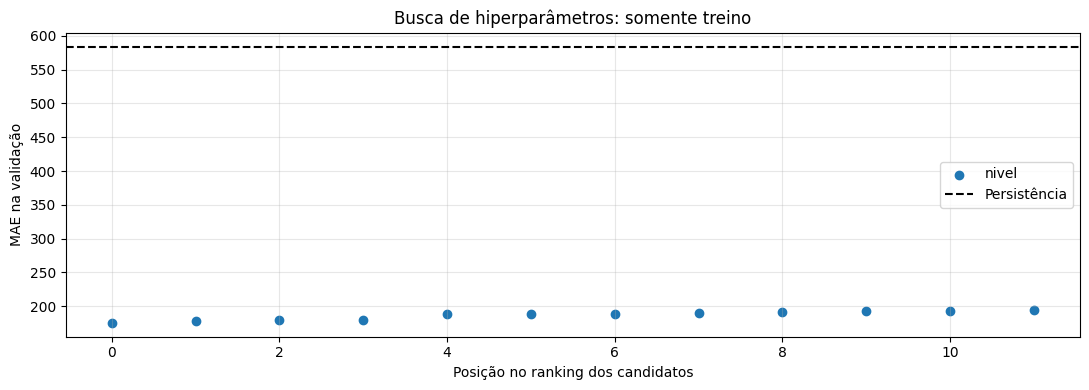

In [5]:
# T11 — busca apenas nas janelas de desenvolvimento do treino.
from sklearn.model_selection import ParameterSampler
from sklearn.base import BaseEstimator, RegressorMixin
from walk_forward import validar_previsoes

MESES_VALIDACAO = 6
N_SPLITS_VALIDACAO = 3
N_CANDIDATOS = 12
N_JOBS = min(4, os.cpu_count() or 1)
ESTRATEGIAS = ('nivel',)
PARAM_GRID = {
    'n_estimators': [100, 200], 'max_depth': [10, None],
    'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 1.0],
}

class FlorestaIncremento(RegressorMixin, BaseEstimator):
    """Prevê a variação sobre t-1; devolve a previsão na escala original."""
    def __init__(self, parametros, seed, n_jobs):
        self.parametros = parametros
        self.seed = seed
        self.n_jobs = n_jobs
    def fit(self, X, y):
        self.floresta_ = RandomForestRegressor(**self.parametros, random_state=self.seed, n_jobs=self.n_jobs)
        self.floresta_.fit(X, np.asarray(y) - X['target_lag_1'].to_numpy())
        self.n_features_in_ = X.shape[1]
        return self
    def predict(self, X):
        return X['target_lag_1'].to_numpy() + self.floresta_.predict(X)

def criar_modelo(parametros, estrategia):
    if estrategia == 'incremento':
        return FlorestaIncremento(parametros, SEED, N_JOBS)
    return RandomForestRegressor(**parametros, random_state=SEED, n_jobs=N_JOBS)

folds, linhas_folds = [], []
for i in range(N_SPLITS_VALIDACAO):
    inicio_val = INICIO_TESTE - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i))
    fim_val = INICIO_TESTE - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1))
    ia = np.flatnonzero(X_train.index < inicio_val)
    iv = np.flatnonzero((X_train.index >= inicio_val) & (X_train.index < fim_val))
    if not len(ia) or not len(iv) or X_train.index[ia].max() >= X_train.index[iv].min():
        raise ValueError('Fold de validação vazio ou fora da ordem temporal.')
    folds.append((ia, iv))
    linhas_folds.append({'fold': i+1, 'treino_ate': X_train.index[ia].max(),
        'validacao_inicio': X_train.index[iv].min(), 'validacao_fim': X_train.index[iv].max(),
        'n_treino': len(ia), 'n_validacao': len(iv)})
display(pd.DataFrame(linhas_folds))

PARAMETROS = list(ParameterSampler(PARAM_GRID, n_iter=N_CANDIDATOS, random_state=SEED))
mae_persistencia_validacao = np.mean(np.concatenate([
    np.abs(y_train.iloc[iv].to_numpy() - X_train.iloc[iv]['target_lag_1'].to_numpy())
    for _, iv in folds
]))
resultados_grid = []
inicio_grid = time.perf_counter()
for estrategia in ESTRATEGIAS:
    for indice, params in enumerate(PARAMETROS):
        erros, maes_fold = [], []
        for ia, iv in folds:
            candidato = criar_modelo(params, estrategia)
            candidato.fit(X_train.iloc[ia], y_train.iloc[ia])
            erro = y_train.iloc[iv].to_numpy() - candidato.predict(X_train.iloc[iv])
            erros.append(erro)
            maes_fold.append(float(np.abs(erro).mean()))
        erros = np.concatenate(erros)
        resultados_grid.append({'estrategia': estrategia, 'indice': indice, **params,
            'MAE_validacao': float(np.abs(erros).mean()),
            'desvio_MAE_folds': float(np.std(maes_fold, ddof=1)),
            'RMSE_validacao': float(np.sqrt(np.mean(erros**2)))})
        print(f"{estrategia} {indice+1}/{len(PARAMETROS)}: MAE={resultados_grid[-1]['MAE_validacao']:.4f}")

df_grid = pd.DataFrame(resultados_grid).sort_values('MAE_validacao').reset_index(drop=True)
BEST_ESTRATEGIA = str(df_grid.loc[0, 'estrategia'])
BEST_PARAMS = PARAMETROS[int(df_grid.loc[0, 'indice'])].copy()
display(df_grid.round(4))
print(f'Persistência na validação: MAE={mae_persistencia_validacao:.4f}')
print(f'Melhor RF: {BEST_ESTRATEGIA}, MAE={df_grid.loc[0, "MAE_validacao"]:.4f}; parâmetros={BEST_PARAMS}')
print(f'Tempo da busca: {(time.perf_counter()-inicio_grid)/60:.1f} min')

fig, ax = plt.subplots(figsize=(11, 4))
for nome, parte in df_grid.groupby('estrategia'):
    ax.scatter(parte.index, parte['MAE_validacao'], label=nome)
ax.axhline(mae_persistencia_validacao, color='black', linestyle='--', label='Persistência')
ax.set(xlabel='Posição no ranking dos candidatos', ylabel='MAE na validação',
       title='Busca de hiperparâmetros: somente treino')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## T12 — RF com parâmetros escolhidos na validação

Ajuste único no treino completo. No teste, os lags são atualizados quando as observações anteriores já estão disponíveis. O protocolo comum confere se todas as datas elegíveis receberam exatamente uma previsão.

In [6]:
modelo = criar_modelo(BEST_PARAMS, BEST_ESTRATEGIA)
inicio = time.perf_counter()
modelo.fit(X_train, y_train)
previsto = modelo.predict(X_test)
tempo_ajuste = time.perf_counter() - inicio
previsoes = pd.DataFrame({
    'real': y_test.to_numpy(), 'random_forest': previsto,
    'persistencia': X_test['target_lag_1'].to_numpy(),
}, index=X_test.index)
previsoes.index.name = 'data'
previsoes['residuo'] = previsoes['real'] - previsoes['random_forest']
print(f"Ajuste e previsão: {tempo_ajuste:.1f} s | previsões: {len(previsoes):,}")
conferencia_t08 = validar_previsoes(BASE_NAME, previsoes.index, PROJECT_ROOT)
assert conferencia_t08['ok'], conferencia_t08
print('T08 — origens de teste:', conferencia_t08)


Ajuste e previsão: 3.1 s | previsões: 10,267


T08 — origens de teste: {'base': 'trafego', 'origens_oficiais': 10267, 'previsoes': 10267, 'duplicadas': 0, 'ordenadas': True, 'faltando': 0, 'fora_do_protocolo': 0, 'ok': True}


## T16 — Métricas preliminares

RF e persistência são comparados nos **mesmos timestamps elegíveis**. O teste completo só será comparável aos demais modelos se eles adotarem essa mesma avaliação. O ranking dos 20 pipelines permanece pendente.

In [7]:
def resumir(nome, real, predito):
    erro = real - predito
    return {
        'modelo': nome, 'n': len(real),
        'MAE': mean_absolute_error(real, predito),
        'RMSE': np.sqrt(mean_squared_error(real, predito)),
        'R2': r2_score(real, predito),
        'desvio_residual': np.std(erro, ddof=1),
        'vies_real_menos_previsto': np.mean(erro),
    }
metricas = pd.DataFrame([
    resumir('Random Forest', previsoes['real'], previsoes['random_forest']),
    resumir('Persistência', previsoes['real'], previsoes['persistencia']),
])
mae_rf = float(metricas.loc[metricas.modelo == 'Random Forest', 'MAE'].iloc[0])
mae_persistencia = float(metricas.loc[metricas.modelo == 'Persistência', 'MAE'].iloc[0])
metricas['ganho_MAE_vs_persistencia_%'] = 100 * (1 - metricas['MAE'] / mae_persistencia)
display(metricas.round(4))
print(f'MAE RF: {mae_rf:.4f} | MAE persistência: {mae_persistencia:.4f} | unidade: {UNIDADE}')
if mae_rf >= mae_persistencia:
    print('Com parâmetros escolhidos na validação, o RF não superou a persistência. A próxima mudança deve ser escolhida na validação do treino.')
else:
    print('Com parâmetros escolhidos na validação, o RF superou a persistência nos períodos elegíveis.')


,modelo,n,MAE,RMSE,R2,desvio_residual,vies_real_menos_previsto,ganho_MAE_vs_persistencia_%
0,Random Forest,10267,153.2877,240.0005,0.9852,240.0102,0.9879,74.0538
1,Persistência,10267,590.7910,818.0348,0.8283,818.0487,-6.5181,0.0000


MAE RF: 153.2877 | MAE persistência: 590.7910 | unidade: veículos por hora
Com parâmetros escolhidos na validação, o RF superou a persistência nos períodos elegíveis.


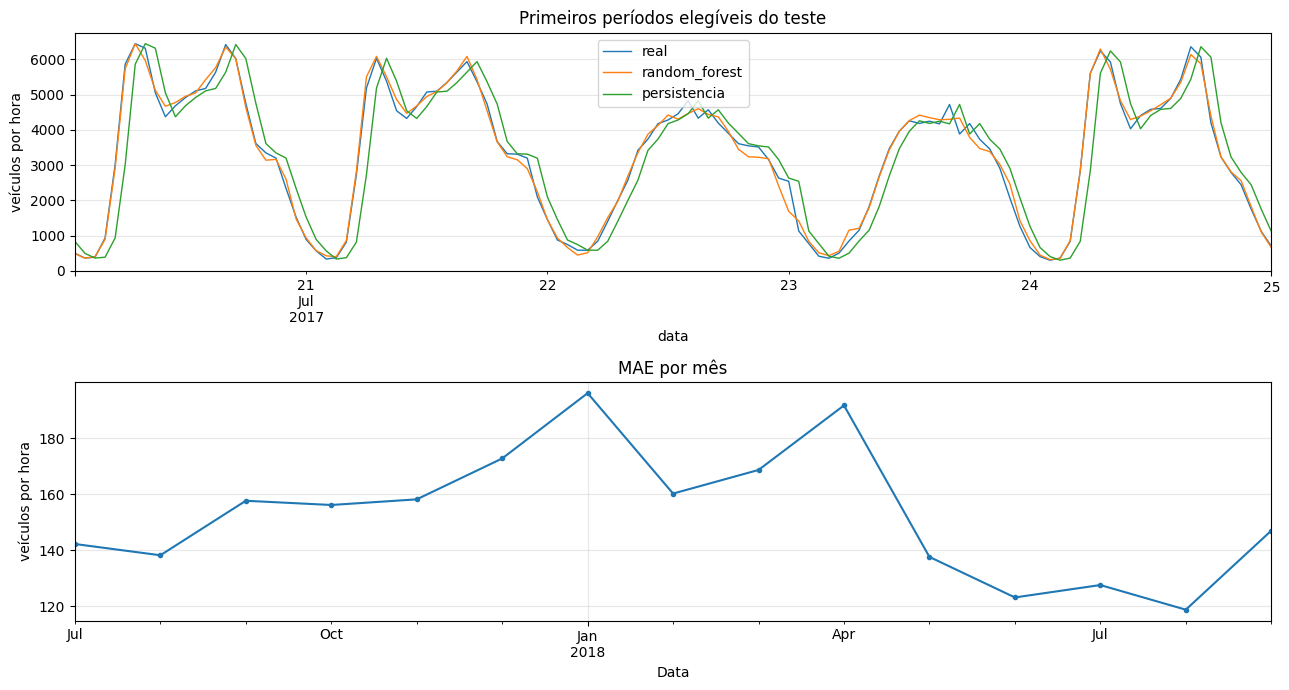

O MAE global acima usa todos os períodos elegíveis, não apenas os mostrados no gráfico superior.


In [8]:
janela = previsoes.iloc[:min(120, len(previsoes))]
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
janela[['real', 'random_forest', 'persistencia']].plot(ax=axes[0], linewidth=1)
axes[0].set(title='Primeiros períodos elegíveis do teste', ylabel=UNIDADE)
periodo_mae = 'MS' if meta['frequencia'] in ('D', 'h') else 'YS'
mae_periodo = previsoes['residuo'].abs().resample(periodo_mae).agg(['mean', 'count'])
mae_periodo.columns = ['MAE', 'n']
mae_periodo.loc[mae_periodo['n'] > 0, 'MAE'].plot(ax=axes[1], marker='o', markersize=3)
axes[1].set(title='MAE por mês' if periodo_mae == 'MS' else 'MAE por ano', ylabel=UNIDADE, xlabel='Data')
for ax in axes: ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('O MAE global acima usa todos os períodos elegíveis, não apenas os mostrados no gráfico superior.')

## T17 — Diagnóstico dos resíduos

A série de erros usa todos os períodos elegíveis do teste. A ACF e o Ljung-Box usam o maior trecho sem lacunas na frequência original, pois saltar períodos mudaria o significado dos lags.

Resíduos: média=0.9879, desvio-padrão=240.0102; ACF no maior trecho contínuo: 1,420 períodos.


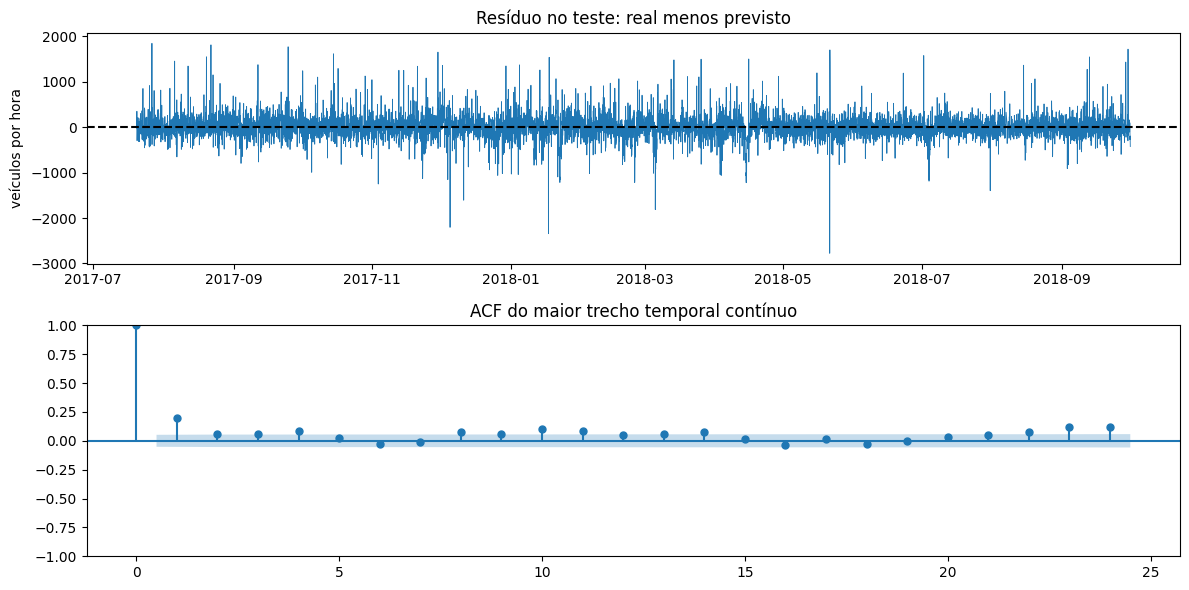

,lb_stat,lb_pvalue
1,54.025840,1.978702e-13
6,75.814492,2.608615e-14
12,118.650510,1.147932e-19
24,191.279715,5.039934e-28


p < 0,05 indica autocorrelação residual; não prova, por si só, inutilidade preditiva.


In [9]:
# T17 — resíduos fora da amostra, sem comprimir lacunas temporais.
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = previsoes['residuo'].sort_index()
passo = pd.Timedelta(hours=1)
blocos = residuos.index.to_series().diff().ne(passo).cumsum()
trecho = max((parte for _, parte in residuos.groupby(blocos.to_numpy())), key=len)
print(f'Resíduos: média={residuos.mean():.4f}, desvio-padrão={residuos.std():.4f}; '
      f'ACF no maior trecho contínuo: {len(trecho):,} períodos.')
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(residuos.index, residuos.to_numpy(), linewidth=.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set(title='Resíduo no teste: real menos previsto', ylabel=UNIDADE)
max_lag = min(24, max(1, len(trecho)//5))
plot_acf(trecho, lags=max_lag, ax=axes[1], title='ACF do maior trecho temporal contínuo')
plt.tight_layout(); plt.show()
lags_lb = [lag for lag in [1, 6, 12, 24] if lag <= max_lag]
display(acorr_ljungbox(trecho, lags=lags_lb, return_df=True))
print('p < 0,05 indica autocorrelação residual; não prova, por si só, inutilidade preditiva.')

## T18 — Importância preliminar das features

Permutação no teste, com amostra fixa de até 500 períodos. O desvio representa a variação entre três permutações. Esta análise é interpretativa; a seleção de atributos ainda deve ocorrer somente na validação do treino.

,feature,importancia,desvio_importancia
0,target_lag_1,586.2597,15.1736
1,hora_cos,352.1178,6.0419
2,target_lag_168,197.9732,7.7729
3,target_lag_24,127.3668,5.6743
4,target_lag_2,111.8710,5.3296
5,hora_sin,100.2370,1.9549
6,target_roll_mean_6,81.4336,2.6885
7,target_roll_std_6,59.5313,5.1882
8,dia_semana_sin,51.8123,1.8136
9,target_lag_48,51.6087,1.8123


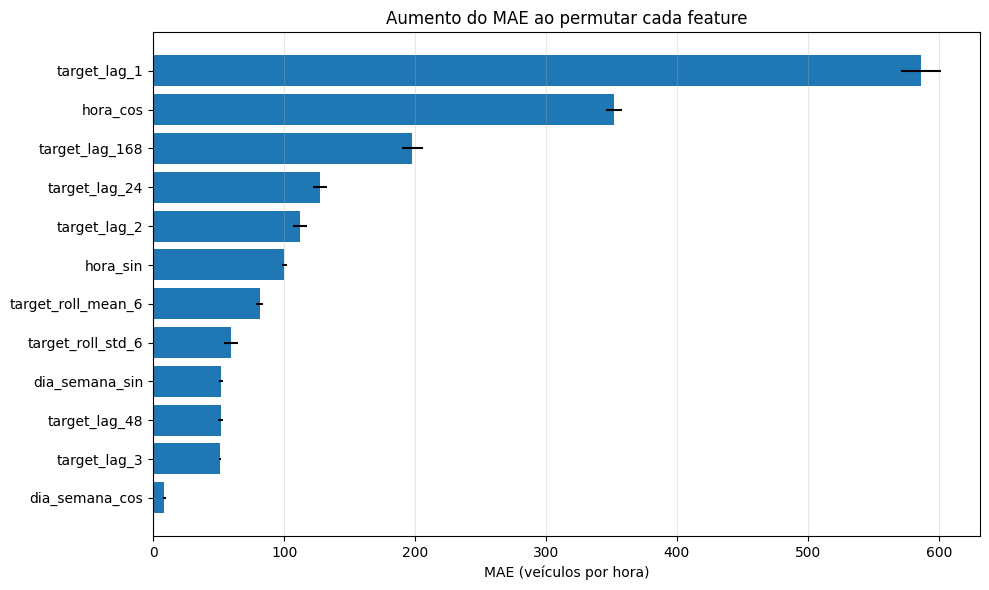

In [10]:
importancias = calcular_importancia_features(
    modelo, X_test, y_test, metodo='permutacao',
    n_repeticoes=3, seed=SEED, n_jobs=1, max_amostras=500,
)
display(importancias[['feature', 'importancia', 'desvio_importancia']].head(12).round(4))
top = importancias.head(12).sort_values('importancia')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['feature'], top['importancia'], xerr=top['desvio_importancia'])
ax.set(title='Aumento do MAE ao permutar cada feature', xlabel=f'MAE ({UNIDADE})')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

## Relatório antes/depois no teste

A configuração anterior é reconstruída com os mesmos hiperparâmetros já escolhidos na sua validação. O MAE **nas datas comuns** isola a mudança do modelo; as datas adicionais e a cobertura mostram o alcance novo. A importância por permutação é medida nas mesmas datas apenas para interpretar o resultado, sem selecionar features pelo teste.


In [11]:
# Reajusta a configuração anterior somente para medir o antes/depois.
base_antiga_treino = antigo_completo.loc[antigo_completo.index < INICIO_TESTE]
base_antiga_teste = antigo_completo.loc[antigo_completo.index >= INICIO_TESTE]
X_antigo_treino = base_antiga_treino.drop(columns='target')
X_antigo_teste = base_antiga_teste.drop(columns='target')
parametros_anteriores = dict(n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features='sqrt', max_depth=None)
modelo_antigo = RandomForestRegressor(**parametros_anteriores, random_state=SEED, n_jobs=N_JOBS)
modelo_antigo.fit(X_antigo_treino, base_antiga_treino['target'])
previsao_antiga = pd.Series(modelo_antigo.predict(X_antigo_teste), index=X_antigo_teste.index)
comuns = previsoes.index.intersection(previsao_antiga.index)
adicionais = previsoes.index.difference(previsao_antiga.index)
def linha_comparacao(nome, datas, previsto):
    real = previsoes.loc[datas, 'real']
    return {'recorte': nome, 'n': len(datas),
            'cobertura_grade_%': 100 * len(datas) / meta['linhas_teste'],
            'MAE': mean_absolute_error(real, previsto)}
comparacao_antes_depois = pd.DataFrame([
    linha_comparacao('Anterior nas datas comuns', comuns, previsao_antiga.loc[comuns]),
    linha_comparacao('Novo nas datas comuns', comuns, previsoes.loc[comuns, 'random_forest']),
    linha_comparacao('Novo nas datas adicionais', adicionais, previsoes.loc[adicionais, 'random_forest']),
    linha_comparacao('Novo em todo teste elegível', previsoes.index, previsoes['random_forest']),
    linha_comparacao('Persistência no teste elegível', previsoes.index, previsoes['persistencia']),
])
display(comparacao_antes_depois.round(4))
print(f'Cobertura anterior: {len(base_antiga_teste)}/{meta["linhas_teste"]}; nova: {len(previsoes)}/{meta["linhas_teste"]}.')

# Mesmas datas e mesma amostragem na leitura interpretativa das importâncias.
importancia_antiga = calcular_importancia_features(
    modelo_antigo, X_antigo_teste.loc[comuns], base_antiga_teste.loc[comuns, 'target'],
    metodo='permutacao', n_repeticoes=3, seed=SEED, n_jobs=1, max_amostras=500,
)
importancia_nova_comum = calcular_importancia_features(
    modelo, X_test.loc[comuns], y_test.loc[comuns],
    metodo='permutacao', n_repeticoes=3, seed=SEED, n_jobs=1, max_amostras=500,
)
for nome, imp in [('Anterior', importancia_antiga), ('Novo', importancia_nova_comum)]:
    print(f'Importância por permutação — {nome}, datas comuns:')
    display(imp[['feature', 'importancia', 'desvio_importancia']].head(10).round(4))


,recorte,n,cobertura_grade_%,MAE
0,Anterior nas datas comuns,7720,73.4469,165.5286
1,Novo nas datas comuns,7720,73.4469,151.7463
2,Novo nas datas adicionais,2547,24.2318,157.9597
3,Novo em todo teste elegível,10267,97.6786,153.2877
4,Persistência no teste elegível,10267,97.6786,590.7910


Cobertura anterior: 7720/10511; nova: 10267/10511.


Importância por permutação — Anterior, datas comuns:


,feature,importancia,desvio_importancia
0,target_lag_1,617.6281,14.6412
1,hora_cos,328.7312,16.1668
2,target_lag_168,235.9946,4.0964
3,target_lag_24,122.5893,3.1167
4,target_lag_2,88.5355,0.8188
5,target_roll_mean_6,54.4225,2.4211
6,hora_sin,53.3118,0.4060
7,dia_semana_sin,46.4609,2.5931
8,target_roll_std_6,44.5007,2.7181
9,target_lag_48,37.7327,0.5366


Importância por permutação — Novo, datas comuns:


,feature,importancia,desvio_importancia
0,target_lag_1,605.6732,16.0084
1,hora_cos,319.1009,18.1081
2,target_lag_168,187.5323,2.9841
3,target_lag_24,116.2432,1.7521
4,target_lag_2,115.7771,3.1869
5,hora_sin,88.8521,1.1674
6,target_roll_mean_6,73.3452,2.9799
7,target_roll_std_6,69.4455,4.5098
8,dia_semana_sin,46.5690,3.1567
9,target_lag_48,45.9299,0.7557


## Experimento: retirar lags para cobrir mais horas

A importância por permutação indica quais entradas ajudam o modelo nas datas em que estão presentes; ela não garante que retirá-las terá o mesmo efeito. Os perfis abaixo são comparados em três blocos temporais do **treino**, com os mesmos hiperparâmetros de diagnóstico. O teste é exibido depois, separando datas comuns e horas adicionais.

O perfil `lag_1_exogenas` serve como candidato de cobertura; a versão híbrida usa o RF atual nas datas já elegíveis e esse perfil somente nas horas adicionais. A versão híbrida é apenas um experimento: o protocolo T08 e os resultados oficiais acima continuam com o perfil atual até que todos os modelos do grupo adotem as novas origens.


In [12]:
colunas_atuais = list(X_train.columns)
perfis_lags = {
    'atual': colunas_atuais,
    'sem_lag_168': [c for c in colunas_atuais if c != 'target_lag_168'],
    'curtos_sem_janela': [c for c in colunas_atuais if not c.startswith('target_roll_')
                          and not (c.startswith('target_lag_') and int(c.rsplit('_', 1)[1]) >= 24)],
    'lag_1_exogenas': [c for c in colunas_atuais if not c.startswith('target_') or c == 'target_lag_1'],
}
origens_atuais = model_data.index
linhas_cv_lags, linhas_teste_lags = [], []
for perfil, colunas in perfis_lags.items():
    dados_perfil = grade_features[['target'] + colunas].dropna()
    treino_perfil = dados_perfil.loc[dados_perfil.index < INICIO_TESTE]
    teste_perfil = dados_perfil.loc[dados_perfil.index >= INICIO_TESTE]
    reais_cv, previstos_cv = [], []
    for i in range(N_SPLITS_VALIDACAO):
        inicio_val = INICIO_TESTE - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i))
        fim_val = INICIO_TESTE - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1))
        fit = treino_perfil.loc[treino_perfil.index < inicio_val]
        val = treino_perfil.loc[(treino_perfil.index >= inicio_val) & (treino_perfil.index < fim_val)]
        candidato = criar_modelo(parametros_diagnostico, BEST_ESTRATEGIA)
        candidato.fit(fit[colunas], fit['target'])
        reais_cv.append(val['target'])
        previstos_cv.append(pd.Series(candidato.predict(val[colunas]), index=val.index))
    real_cv = pd.concat(reais_cv)
    pred_cv = pd.concat(previstos_cv)
    comum_cv = real_cv.index.intersection(origens_atuais)
    adicional_cv = real_cv.index.difference(origens_atuais)
    linhas_cv_lags.append({
        'perfil': perfil, 'n_validacao': len(real_cv), 'n_adicionais': len(adicional_cv),
        'MAE_todas': mean_absolute_error(real_cv, pred_cv),
        'MAE_comuns': mean_absolute_error(real_cv.loc[comum_cv], pred_cv.loc[comum_cv]),
        'MAE_adicionais': mean_absolute_error(real_cv.loc[adicional_cv], pred_cv.loc[adicional_cv])
        if len(adicional_cv) else np.nan,
    })
    if perfil == 'atual':
        pred_teste = previsoes['random_forest']
    else:
        candidato_final = criar_modelo(BEST_PARAMS, BEST_ESTRATEGIA)
        candidato_final.fit(treino_perfil[colunas], treino_perfil['target'])
        pred_teste = pd.Series(candidato_final.predict(teste_perfil[colunas]), index=teste_perfil.index)
    comum_teste = pred_teste.index.intersection(previsoes.index)
    adicional_teste = pred_teste.index.difference(previsoes.index)
    # A alternativa híbrida conserva todas as previsões oficiais e acrescenta apenas datas novas.
    pred_hibrida = pd.concat([previsoes['random_forest'], pred_teste.loc[adicional_teste]]).sort_index()
    linhas_teste_lags.append({
        'perfil': perfil, 'n_teste': len(pred_teste),
        'cobertura_grade_%': 100 * len(pred_teste) / meta['linhas_teste'],
        'MAE_todas': mean_absolute_error(teste_perfil['target'], pred_teste),
        'MAE_comuns': mean_absolute_error(teste_perfil.loc[comum_teste, 'target'], pred_teste.loc[comum_teste]),
        'n_adicionais': len(adicional_teste),
        'MAE_adicionais': mean_absolute_error(teste_perfil.loc[adicional_teste, 'target'], pred_teste.loc[adicional_teste])
        if len(adicional_teste) else np.nan,
        'MAE_hibrido': mean_absolute_error(grade_features.loc[pred_hibrida.index, 'target'], pred_hibrida),
    })
validacao_lags = pd.DataFrame(linhas_cv_lags)
comparacao_lags = pd.DataFrame(linhas_teste_lags)
print('Validação temporal — somente treino:')
display(validacao_lags.round(4))
print('Teste — datas comuns, novas e híbrido:')
display(comparacao_lags.round(4))
print('Horas com alvo observado:', int(grade_features.loc[grade_features.index >= INICIO_TESTE, 'target'].notna().sum()))


Validação temporal — somente treino:


,perfil,n_validacao,n_adicionais,MAE_todas,MAE_comuns,MAE_adicionais
0,atual,10172,0,176.0261,176.0261,NaN
1,sem_lag_168,10364,192,175.2051,175.5193,158.5594
2,curtos_sem_janela,11016,844,176.1935,177.4187,161.4276
3,lag_1_exogenas,11598,1426,181.1333,182.5897,170.7445


Teste — datas comuns, novas e híbrido:


,perfil,n_teste,cobertura_grade_%,MAE_todas,MAE_comuns,n_adicionais,MAE_adicionais,MAE_hibrido
0,atual,10267,97.6786,153.2877,153.2877,0,NaN,153.2877
1,sem_lag_168,10296,97.9545,151.2355,151.4421,29,78.0877,153.0759
2,curtos_sem_janela,10416,99.0962,151.5806,151.7021,149,143.2079,153.1435
3,lag_1_exogenas,10458,99.4958,157.7766,157.9491,191,148.5013,153.2003


Horas com alvo observado: 10479


### Limites e próximos passos

A configuração foi escolhida em validação temporal e as previsões cobrem as origens elegíveis do protocolo T08. A comparação final dos 20 pipelines depende das execuções dos demais modelos nas mesmas datas. A estratégia de reajuste periódico continua específica de cada família de modelo e deve ser declarada no relatório.

In [8]:
from IPython.display import display
from walk_forward import validar_previsoes
assert validar_previsoes(BASE_NAME, previsoes.index, PROJECT_ROOT)["ok"]
print(f"MAE RECONSTRUIDO: {np.mean(np.abs(previsoes.real-previsoes.random_forest)):.8f} | n={len(previsoes)}")
resultado=[{"data":str(d),"real":float(r),"previsto":float(v)} for d,r,v in previsoes[["real","random_forest"]].itertuples()]
import base64, zlib, json
_carga_compacta = base64.b64encode(zlib.compress(json.dumps(resultado, ensure_ascii=False, separators=(',', ':'), allow_nan=False).encode('utf-8'), 9)).decode('ascii')
display({'application/vnd.series-temporais.previsoes+json': {'formato': 'json-zlib-base64', 'dados': _carga_compacta}}, raw=True)

MAE RECONSTRUIDO: 153.28771701 | n=10267
